In [1]:
import os
import numpy as np

def load_dr_dataset(root_dir):
    classes = sorted([
        d for d in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, d))
    ])
    
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    
    image_paths = []
    labels = []

    for cls in classes:
        cls_dir = os.path.join(root_dir, cls)
        for file in os.listdir(cls_dir):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(cls_dir, file))
                labels.append(class_to_idx[cls])

    return image_paths, np.array(labels), classes


In [2]:
DATA_DIR = "/Users/samreddyvarunreddy/Desktop/datamining/Dataset"
img_paths, y_true, class_names = load_dr_dataset(DATA_DIR)

In [3]:
print("Total images:", len(img_paths))
print("Classes:", class_names)
print("Class counts:")

for i, cls in enumerate(class_names):
    print(f"{cls:15s}: {(y_true == i).sum()}")


Total images: 2750
Classes: ['Healthy', 'Mild DR', 'Moderate DR', 'Proliferate DR', 'Severe DR']
Class counts:
Healthy        : 1000
Mild DR        : 370
Moderate DR    : 900
Proliferate DR : 290
Severe DR      : 190


In [7]:
import numpy as np
import torch
from torchvision import models, transforms
from PIL import Image
from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cpu


In [8]:
resize_transform = transforms.Resize((224, 224))


In [9]:
normalize_transform = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225])

In [10]:
preprocess = transforms.Compose([
    resize_transform,
    transforms.ToTensor(),
    normalize_transform
])

def load_image_tensor(path):
    img = Image.open(path).convert("RGB")
    return preprocess(img)


In [11]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet = resnet.to(DEVICE)
resnet.eval()

print(resnet)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/samreddyvarunreddy/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 23.9MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [12]:
_hook_features = []

def forward_hook(module, input, output):
    pooled = output.mean(dim=(2, 3))
    _hook_features.append(pooled.detach().cpu())

hook_handle = resnet.layer4.register_forward_hook(forward_hook)


In [13]:
@torch.no_grad()
def extract_resnet18_features(image_paths, batch_size=32):
    features = []

    for i in tqdm(range(0, len(image_paths), batch_size),
                  desc="Extracting ResNet18 features"):
        batch_paths = image_paths[i:i+batch_size]

        batch = torch.stack(
            [load_image_tensor(p) for p in batch_paths]
        ).to(DEVICE)

        _hook_features.clear()
        _ = resnet(batch)     

        batch_features = _hook_features[0] 
        features.append(batch_features.numpy())

    return np.vstack(features)


In [14]:
X = extract_resnet18_features(img_paths, batch_size=32)

hook_handle.remove()

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y_true.shape)


Extracting ResNet18 features:   0%|          | 0/86 [00:00<?, ?it/s]

Feature matrix shape: (2750, 512)
Label vector shape: (2750,)


In [15]:
assert X.shape[0] == y_true.shape[0]
print("NaN values in X:", np.isnan(X).sum())


NaN values in X: 0


In [ ]:
### References
Kozodoi, N. (2021). Extracting Intermediate Layer Outputs in PyTorch.  
https://kozodoi.me/blog/20210527/extracting-features

PyTorch Documentation: Forward Hooks  
https://pytorch.org/docs/stable/generated/torch.nn.modules.module.register_module_forward_hook.html


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature shape:", X_scaled.shape)


Scaled feature shape: (2750, 512)


In [18]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

print("2D representation shape:", X_2d.shape)


2D representation shape: (2750, 2)


In [19]:
import numpy as np

print("NaNs in X_2d:", np.isnan(X_2d).sum())
assert X_2d.shape[0] == X.shape[0]


NaNs in X_2d: 0


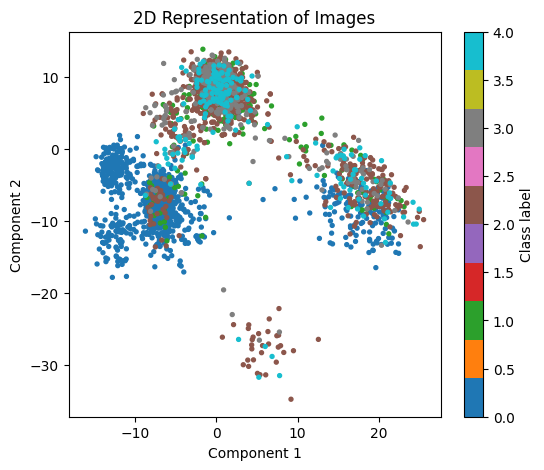

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap="tab10", s=8)
plt.colorbar(label="Class label")
plt.title("2D Representation of Images")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()


In [21]:
#3
import numpy as np
from sklearn.cluster import KMeans, BisectingKMeans, SpectralClustering
K = 4
SEED = 42


In [ ]:
#3a
kmeans_random = KMeans(
    n_clusters=K,
    init="random",
    n_init=10,
    random_state=SEED
)

labels_km_random = kmeans_random.fit_predict(X_2d)

print("KMeans (random) clusters:", np.unique(labels_km_random))
print("Cluster counts:", np.bincount(labels_km_random))


KMeans (random) clusters: [0 1 2 3]
Cluster counts: [  40  967  423 1320]


In [23]:
#3b
kmeans_pp = KMeans(
    n_clusters=K,
    init="k-means++",
    n_init=10,
    random_state=SEED
)

labels_km_pp = kmeans_pp.fit_predict(X_2d)

print("KMeans (k-means++) clusters:", np.unique(labels_km_pp))
print("Cluster counts:", np.bincount(labels_km_pp))


KMeans (k-means++) clusters: [0 1 2 3]
Cluster counts: [  40 1320  423  967]


In [24]:
#c
bisect_km = BisectingKMeans(
    n_clusters=K,
    init="random",
    random_state=SEED
)

labels_bisect = bisect_km.fit_predict(X_2d)

print("BisectingKMeans (random) clusters:", np.unique(labels_bisect))
print("Cluster counts:", np.bincount(labels_bisect))


BisectingKMeans (random) clusters: [0 1 2 3]
Cluster counts: [1353   35  395  967]


In [ ]:
#d
spectral = SpectralClustering(
    n_clusters=K,
    random_state=SEED
)

labels_spectral = spectral.fit_predict(X_2d)

print("SpectralClustering clusters:", np.unique(labels_spectral))
print("Cluster counts:", np.bincount(labels_spectral))


SpectralClustering clusters: [0 1 2 3]
Cluster counts: [1351   40  430  929]


In [26]:
#DBSCAN
from sklearn.cluster import DBSCAN
def count_dbscan_clusters(labels):
    return len(set(labels)) - (1 if -1 in labels else 0)


In [27]:
eps_values = np.linspace(0.1, 5.0, 30)
min_samples_values = [3, 4, 5, 6, 8, 10]

best_params = None

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_2d)

        n_clusters = count_dbscan_clusters(labels)

        if n_clusters == 4:
            best_params = (eps, ms)
            print(f"Found 4 clusters with eps={eps:.2f}, min_samples={ms}")
            break
    if best_params:
        break


Found 4 clusters with eps=1.28, min_samples=5


In [28]:
eps_used = best_params[0]
min_samples_used = best_params[1]

dbscan = DBSCAN(
    eps=eps_used,
    min_samples=min_samples_used
)

labels_dbscan = dbscan.fit_predict(X_2d)

print("Unique labels:", np.unique(labels_dbscan))
print("Number of clusters:", count_dbscan_clusters(labels_dbscan))
print("Noise points:", np.sum(labels_dbscan == -1))


Unique labels: [-1  0  1  2  3]
Number of clusters: 4
Noise points: 90


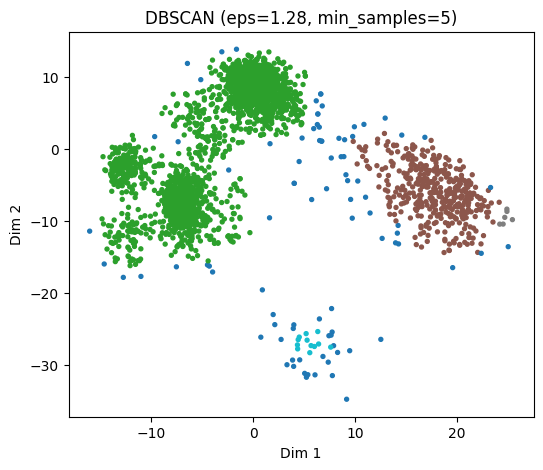

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=labels_dbscan,
    s=8,
    cmap="tab10"
)
plt.title(f"DBSCAN (eps={eps_used:.2f}, min_samples={min_samples_used})")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()


In [30]:
#Agglomerative clustering
from sklearn.cluster import AgglomerativeClustering
K = 4

In [31]:
agg_single = AgglomerativeClustering(
    n_clusters=K,
    linkage="single"
)

labels_single = agg_single.fit_predict(X_2d)

print("Single-link clusters:", np.unique(labels_single))
print("Cluster counts:", np.bincount(labels_single))


Single-link clusters: [0 1 2 3]
Cluster counts: [  38 2710    1    1]


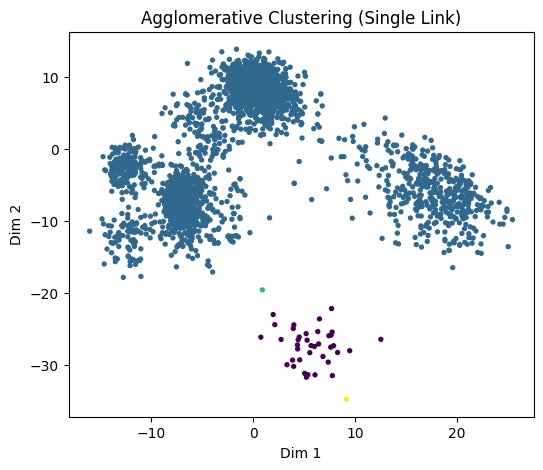

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_single, s=8)
plt.title("Agglomerative Clustering (Single Link)")
plt.xlabel("Dim 1"); plt.ylabel("Dim 2")
plt.show()


In [33]:
agg_complete = AgglomerativeClustering(
    n_clusters=K,
    linkage="complete"
)

labels_complete = agg_complete.fit_predict(X_2d)

print("Complete-link clusters:", np.unique(labels_complete))
print("Cluster counts:", np.bincount(labels_complete))


Complete-link clusters: [0 1 2 3]
Cluster counts: [ 439  924   40 1347]


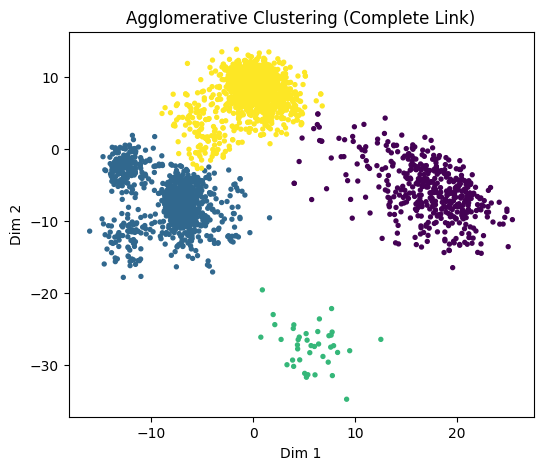

In [34]:
plt.figure(figsize=(6,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_complete, s=8)
plt.title("Agglomerative Clustering (Complete Link)")
plt.xlabel("Dim 1"); plt.ylabel("Dim 2")
plt.show()


In [35]:
agg_average = AgglomerativeClustering(
    n_clusters=K,
    linkage="average"
)

labels_average = agg_average.fit_predict(X_2d)

print("Average-link clusters:", np.unique(labels_average))
print("Cluster counts:", np.bincount(labels_average))


Average-link clusters: [0 1 2 3]
Cluster counts: [ 430   40  929 1351]


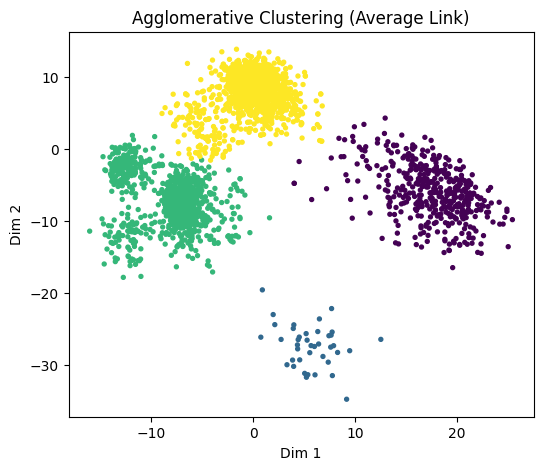

In [36]:
plt.figure(figsize=(6,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_average, s=8)
plt.title("Agglomerative Clustering (Average Link)")
plt.xlabel("Dim 1"); plt.ylabel("Dim 2")
plt.show()


In [37]:
agg_ward = AgglomerativeClustering(
    n_clusters=K,
    linkage="ward"
)

labels_ward = agg_ward.fit_predict(X_2d)

print("Ward clusters:", np.unique(labels_ward))
print("Cluster counts:", np.bincount(labels_ward))


Ward clusters: [0 1 2 3]
Cluster counts: [ 928  430 1352   40]


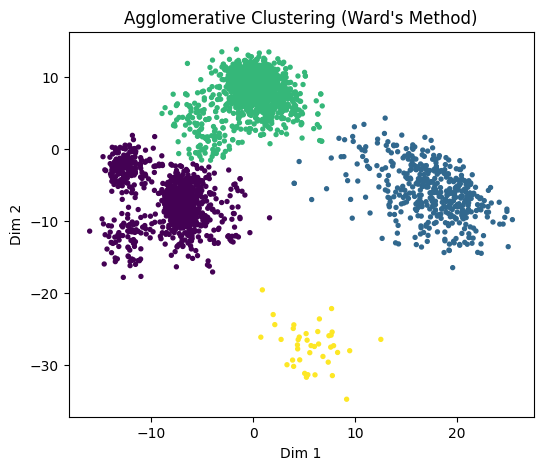

In [38]:
plt.figure(figsize=(6,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_ward, s=8)
plt.title("Agglomerative Clustering (Ward's Method)")
plt.xlabel("Dim 1"); plt.ylabel("Dim 2")
plt.show()


In [39]:
import pandas as pd
from sklearn.metrics import fowlkes_mallows_score, silhouette_score

In [40]:
cluster_results = {
    "KMeans (Random)": labels_km_random,
    "KMeans (k-means++)": labels_km_pp,
    "Bisecting KMeans": labels_bisect,
    "Spectral Clustering": labels_spectral,
    "DBSCAN": labels_dbscan,
    "Agglomerative (Single)": labels_single,
    "Agglomerative (Complete)": labels_complete,
    "Agglomerative (Average)": labels_average,
    "Agglomerative (Ward)": labels_ward
}


In [42]:
def compute_silhouette(X, labels):
    mask = labels != -1
    unique_labels = np.unique(labels[mask])
    if len(unique_labels) < 2:
        return np.nan
    return silhouette_score(X[mask], labels[mask])


In [43]:
rows = []

for method, labels in cluster_results.items():
    fm = fowlkes_mallows_score(y_true, labels)
    sil = compute_silhouette(X_2d, labels)

    rows.append({
        "Method": method,
        "Fowlkes-Mallows": fm,
        "Silhouette": sil
    })

df_results = pd.DataFrame(rows)
df_results


,Method,Fowlkes-Mallows,Silhouette
0,KMeans (Random),0.560910,0.693951
1,KMeans (k-means++),0.560910,0.693951
2,Bisecting KMeans,0.561358,0.677266
3,Spectral Clustering,0.567207,0.689447
4,DBSCAN,0.438867,0.490704
5,Agglomerative (Single),0.515308,0.298477
6,Agglomerative (Complete),0.565055,0.684445
7,Agglomerative (Average),0.568416,0.689411
8,Agglomerative (Ward),0.567651,0.689128


In [46]:
#the clustering methods ranked from best to worst are:
fm_ranked = df_results.sort_values(
    by="Fowlkes-Mallows",
    ascending=False
).reset_index(drop=True)

fm_ranked[["Method", "Fowlkes-Mallows"]]


,Method,Fowlkes-Mallows
0,Agglomerative (Average),0.568416
1,Agglomerative (Ward),0.567651
2,Spectral Clustering,0.567207
3,Agglomerative (Complete),0.565055
4,Bisecting KMeans,0.561358
5,KMeans (Random),0.560910
6,KMeans (k-means++),0.560910
7,Agglomerative (Single),0.515308
8,DBSCAN,0.438867


In [47]:
#the clustering methods ranked from best to worst are:
sil_ranked = df_results.sort_values(
    by="Silhouette",
    ascending=False
).reset_index(drop=True)

sil_ranked[["Method", "Silhouette"]]


,Method,Silhouette
0,KMeans (Random),0.693951
1,KMeans (k-means++),0.693951
2,Spectral Clustering,0.689447
3,Agglomerative (Average),0.689411
4,Agglomerative (Ward),0.689128
5,Agglomerative (Complete),0.684445
6,Bisecting KMeans,0.677266
7,DBSCAN,0.490704
8,Agglomerative (Single),0.298477
